In [1]:
from firedrake import *
from firedrake.output import VTKFile
import matplotlib.pyplot as plt
import numpy as np
from firedrake.petsc import PETSc
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
io_path = current_path + "/cfd-labs/Lab11-NS-Boussinesq/" 
print(io_path)

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


/home/aless/cfd-labs/Lab11-NS-Boussinesq/


# Ex.1 NS: Boussinesq buoyancy model

The problem reads as follows: find $\mathbf{u}=(u_1,u_2)$, $p$ and $T$ such that

$$
\begin{cases}
-\nu\Delta\mathbf{u}
+(\mathbf{u}\cdot\nabla)\mathbf{u}
+\nabla p
+\beta g (T-T_{\mathrm{ref}})
=0,
& \text{in }\Omega,
\\

\nabla\cdot\mathbf{u}=0,
& \text{in }\Omega,
\\

-k\Delta T+\mathbf{u}\cdot\nabla T=0,
& \text{in }\Omega,
\\

\mathbf{u}=(1,0),\quad T=10,
& \text{on }\Gamma_{\mathrm{in}} = \Gamma_{1},
\\

\nu\partial_n\mathbf{u}-pn=0,\quad \partial_n T=0,
& \text{on }\Gamma_{\mathrm{out}} = \Gamma_{2},\\

\partial_n u_1=0,\quad u_2=0,\quad \partial_n T=0,
& \text{on }\Gamma_{\mathrm{bottom,free}} = \Gamma_{31},
\\

\mathbf{u}=0,\quad T=20,
& \text{on }\Gamma_{\mathrm{heated}} = \Gamma_{32},
\\

\partial_n u_1=0,\quad u_2=0,\quad \partial_n T=0,
& \text{on }\Gamma_{\mathrm{top}} = \Gamma_{4}.

\end{cases}
$$

We use a fixed point method and we stabilize the advection-diffusion recation of $T$ usingn the SUPG method.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (31,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (32,) is empty. This is likely an error. Did you choose the right label?


(np.float64(-0.15000000000000002),
 np.float64(3.15),
 np.float64(-0.05),
 np.float64(1.05))

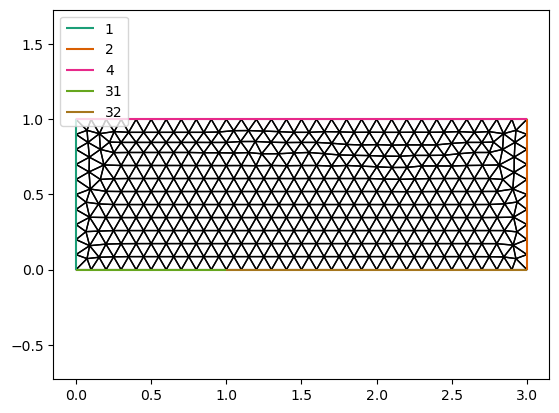

In [2]:
# Import mesh: set the path correctly!
# See cell before Exercise 1 about current path.
mesh = Mesh(io_path + 'mesh/hotplate.msh')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')
ax.axis('equal')

In [3]:
# Function spaces
V = VectorFunctionSpace(mesh, "P", 2)   # velocity
Q = FunctionSpace(mesh, "P", 1)         # pressure
W = MixedFunctionSpace([V, Q])
Z = FunctionSpace(mesh, "P", 1)         # temperature

# Data
nu = Constant(0.1)
k = Constant(1.e-3)
beta = Constant(1.e-4)
g = Constant((0,-9.8))
T_ref = Constant(0)
f = Constant((0.,0.))

# Boundary conditions

# Γ1: inflow
# Inflow velocity profile
u_in = Constant((1., 0.))
bc_U_inflow = DirichletBC(W.sub(0), u_in, 1)
# Inflow temperature
T_in = Constant(10.)
bc_T_inflow = DirichletBC(Z, T_in, 1)

# Γ2: outflow
# Homogeneous Neumann for the outflow velocity and temperature

# Γ31: free bottom wall
# Free-slip for the velocity: u.n = 0, n x (grad(u).n) = 0
bc_U_free = DirichletBC(W.sub(0).sub(1), Constant(0.), 31)
# Homogeneous Neumann for the temperature
# /

# Γ32: heated bottom wall
# No-slip for the velocity: u = 0
bc_U_heated = DirichletBC(W.sub(0), Constant((0., 0.)), 32)
# Dirichlet for the temperature
bc_T_heated = DirichletBC(Z, Constant(20.), 32)

# Γ4: top wall
# Free-slip for the velocity: u.n = 0, n x (grad(u).n) = 0
bc_U_top = DirichletBC(W.sub(0).sub(1), Constant(0.), 4)
# Homogeneous Neumann for the temperature
# /

# Free
bcsU = [bc_U_inflow, bc_U_free, bc_U_heated, bc_U_top]
bcsT = [bc_T_inflow, bc_T_heated]

In [4]:
# Forms/variational problems for the nonlinear iterations

def nonlinear_iteration_NS(u, v, p, q, nu, beta, g, T_ref, f, T, u_old):
    # Implementing fixed-point method for Navier-Stokes equations with thermal source.
    # u,p   :   TrialFunctions
    # v,q   :   TestFunctions
    # f     :   rhs of NS momentum equation
    # T     :   temperature Function
    # u_old :   advecting velocity Function
    a = Constant(nu)*inner(grad(u), grad(v))*dx + inner(dot(grad(u), u_old), v)*dx - div(v)*p*dx + q*div(u)*dx 
    L = inner(f, v)*dx - beta*inner(g, v)*(T-T_ref)*dx
    return a, L

def nonlinear_iteration_thermal(T, eta, k, f, u, stabilization=False):
    # Implementing fixed-point method for Navier-Stokes equations with thermal source.
    # T     :   TrialFunction
    # eta   :   TestFunction
    # f     :   rhs of thermal equation
    # u     :   advecting velocity Function
    a = Constant(k)*inner(grad(T), grad(eta))*dx + inner(dot(grad(T), u), eta)*dx
    L = f*eta*dx
    if stabilization:
        # coefficient delta_K
        ubar = Function(FunctionSpace(mesh, 'DG', 0))
        ubar.project(sqrt(inner(u, u)))
        h = CellDiameter(mesh)
        delta_K = Function(ubar.function_space())
        delta_K = 0.5 * h / (ubar+1e-15)
        a += delta_K*(- Constant(k)*div(grad(T))+inner(u, grad(T)))*(inner(u, grad(eta))+0.5*div(u)*eta)*dx
    return a, L

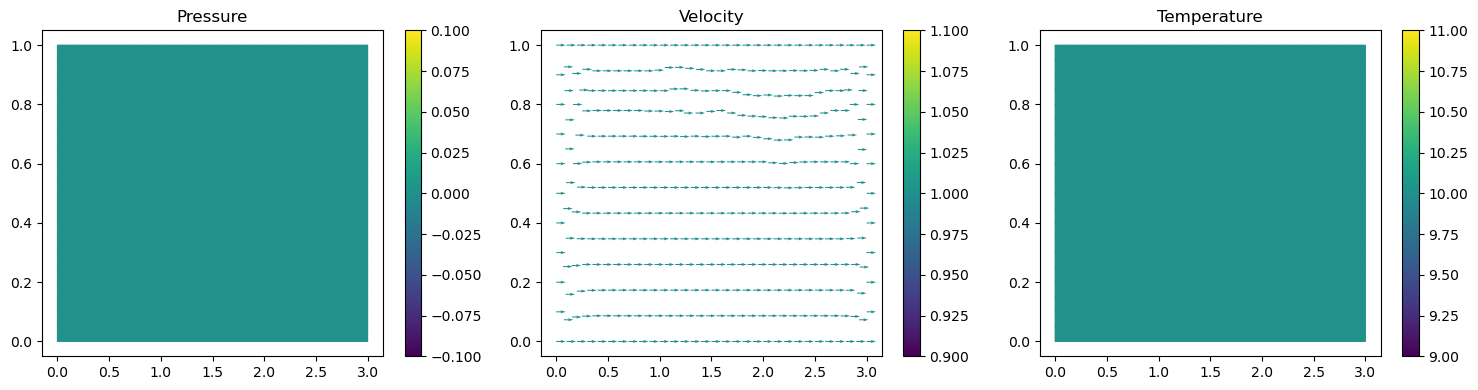

In [5]:
# Initial guess
wh = Function(W)
uh, ph = wh.subfunctions
uh.interpolate(u_in)
Th = Function(Z)
Th.interpolate(T_in)

# Plot the initial guess
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pressure
col1 = tripcolor(ph, axes=axes[0])
fig.colorbar(col1, ax=axes[0])
axes[0].set_title('Pressure')

# Velocity
col2 = quiver(uh, axes=axes[1])
fig.colorbar(col2, ax=axes[1])
axes[1].set_title('Velocity')

# Temperature
col3 = tripcolor(Th, axes=axes[2])
fig.colorbar(col3, ax=axes[2])
axes[2].set_title('Temperature')

plt.tight_layout()
plt.show()

# vtk output for Paraview
outdir = io_path+"output/"
outfile = VTKFile(outdir+"solution.pvd")
uh.rename("Velocity")  
ph.rename("Pressure")
Th.rename("Temperature")
outfile.write(uh, ph, Th)

In [6]:
# Nonlinear solver definition: linear variational problem for the Picard iteration

# Velocity-pressure problem
u, p = TrialFunctions(W)
v, q = TestFunctions(W)
u_old = Function(V)
u_old.assign(uh)
p_old = Function(Q)
p_old.assign(ph)
aU, LU = nonlinear_iteration_NS(u, v, p, q, nu, beta, g, T_ref, f, Th, u_old)
pbU = LinearVariationalProblem(aU, LU, wh, bcsU)
solverU =  LinearVariationalSolver(pbU, solver_parameters={'ksp_type': 'preonly', 'pc_type': 'lu'})

# Thermal problem
T = TrialFunction(Z)
eta = TestFunction(Z)
T_old = Function(Z)
T_old.assign(Th)
STABILIZATION = True
aT, LT = nonlinear_iteration_thermal(T, eta, k, Constant(0.), uh, stabilization=STABILIZATION)
pbT = LinearVariationalProblem(aT, LT, Th, bcsT)
solverT =  LinearVariationalSolver(pbT, solver_parameters={'ksp_type': 'preonly', 'pc_type': 'lu'})

In [7]:
maxit = 100
it = 0
tol = 1e-4
err = tol+1     # >tol in order to enter the loop at the beginning

while it <= maxit and err > tol:
    
    it += 1

    solverU.solve()
    uh, ph = wh.subfunctions
    if STABILIZATION:
        aT, LT = nonlinear_iteration_thermal(T, eta, k, Constant(0.), uh, stabilization=True)
        pbT = LinearVariationalProblem(aT, LT, Th, bcsT)
        solverT =  LinearVariationalSolver(pbT, solver_parameters={'ksp_type': 'preonly', 'pc_type': 'lu'})
    solverT.solve()
    
    err = errornorm(uh, u_old, 'H1') / norm(u_old, 'H1') + errornorm(Th, T_old, 'H1') / norm(T_old, 'H1')
    
    print("--------------------------------")
    print(f"Step : {it}")
    print(f"Error: {err}")
    uh.rename("Velocity")
    ph.rename("Pressure")
    Th.rename("Temperature")
    outfile.write(uh, ph, Th)
    u_old.assign(uh)
    p_old.assign(ph)
    T_old.assign(Th)

print("--------------------------------")

if it <= maxit:
    print('Nonlinear solver converged in', it, 'iterations.')
else:
    print('Nonlinear solver did NOT converge!\nRelative error =', err, 'after', it, 'iterations.')
print("--------------------------------")

--------------------------------
Step : 1
Error: 3.5728800935324276
--------------------------------
Step : 2
Error: 0.06657316006005164
--------------------------------
Step : 3
Error: 0.004787460893312288
--------------------------------
Step : 4
Error: 0.0002513260037327328
--------------------------------
Step : 5
Error: 1.2082576838119084e-05
--------------------------------
Nonlinear solver converged in 5 iterations.
--------------------------------


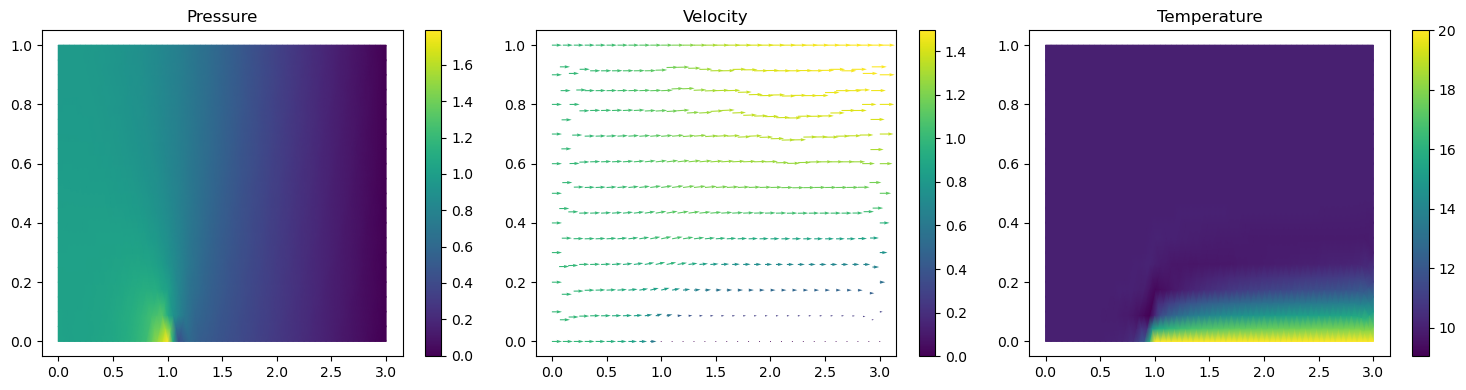

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pressure
col1 = tripcolor(ph, axes=axes[0])
fig.colorbar(col1, ax=axes[0])
axes[0].set_title('Pressure')

# Velocity
col2 = quiver(uh, axes=axes[1])
fig.colorbar(col2, ax=axes[1])
axes[1].set_title('Velocity')

# Temperature
col3 = tripcolor(Th, axes=axes[2])
fig.colorbar(col3, ax=axes[2])
axes[2].set_title('Temperature')

plt.tight_layout()
plt.show()